# Workshop: Poisson Regression in TensorFlow

### Monday, April 25

Today's exercises will illustrate a bit about the basics of TensorFlow.

Today, we'll build and train a simple model, extending what we saw in the lecture videos from the case of a simple linear model to the case of Poisson regression.

## Review: Poisson regression

Given predictor-response pairs $(X_i,Y_i)$ with $X_i \in \mathbb{R}^d$ and $Y_i \in \mathbb{R}$, <a href="https://en.wikipedia.org/wiki/Poisson_regression">Poisson regression</a> models the response $Y_i$ as being distributed according to a Poisson with mean $\lambda(X_i) = \exp\{ \alpha + \beta^T X_i\}$.
That is, for $y=0,1,2,\dots$,
$$
\Pr[ Y_i=y \mid X_i=x, \alpha, \beta] = \frac{ e^{y(\beta^T x + \alpha)} e^{-\exp\{ \beta^T x + \alpha\} } }{ y! }.
$$
t[ Y_i (\beta^T X_i + \alpha) - \exp\{ \beta^T X_i + \alpha\} \right]
$$

Our goal is to implement this model, and then use TF's built-in optimizers to maximize the likelihood of this model with respect to $\alpha$ and $\beta$.

<b>Reminder:</b> if you have not already installed TensorFlow on your local machine, do so with `pip install tensorflow`.

In [1]:
import tensorflow as tf
print(tf.__version__)

2023-04-24 18:14:55.375669: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.12.0


In today's exercises, we're going to focus on using the `keras.Module` class for implementing our models. This has some minor drawbacks when the time comes to upload our models to a server and do prediction, but it is a much simpler class to work with, so we'll use it for now.

## Review: TF tensors and all that

First things first, let's review the difference between constant tensors and variable tensors in TF.

Here are a couple of illustrative constant tensors. Recall that constant tensors are immutable, in much the same way as Python tuples are.

In [2]:
identity = tf.constant([[1,0,0],[0,1,0],[0,0,1]], dtype=tf.float32)
print(identity)

tf.Tensor(
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]], shape=(3, 3), dtype=float32)


In [3]:
oneThruTwelve = tf.constant([[1,2,3],[4,5,6],[7,8,9],[10,11,12]], dtype=tf.float32)
print(oneThruTwelve)

tf.Tensor(
[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]], shape=(4, 3), dtype=float32)


If we try to change entries in these, we get an error.

In [4]:
oneThruTwelve[1,1] = 3.1415

TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

This is going to be a problem if we want to change the parameters of a model during optimization!

Luckily, we have variable tensors, which do support item assignment, updating, etc.

In [5]:
a = tf.Variable( [1,2,3], dtype=tf.float32)
print(a)

<tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>


In [6]:
a[1] = 10

TypeError: 'ResourceVariable' object does not support item assignment

Hey! What the heck?! I thought we were allowed to do this!

Well, it's a bit more complicated than that.
Because TF code is designed so that we can, in the end, build a function graph, we have to use its built-in commands for updating.

In [7]:
a.assign([2,3,4])

<tf.Variable 'UnreadVariable' shape=(3,) dtype=float32, numpy=array([2., 3., 4.], dtype=float32)>

In [8]:
a[1].assign(-1)

<tf.Variable 'UnreadVariable' shape=(3,) dtype=float32, numpy=array([ 2., -1.,  4.], dtype=float32)>

In [9]:
a

<tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([ 2., -1.,  4.], dtype=float32)>

Recall from lecture the way we incorporated this into a simple linear model.

Our first naive solution involved writing a function that takes a slope and intercept and applies that slope and intercept to a given observation $x$.

In [10]:
def linear_prediction_pyfn(c,d,x):
    return c*x + d
# Reminder: we have to turn a regular Python function into a TF function
# for inclusion in the function graph.
linear_model = tf.function(linear_prediction_pyfn)

In [11]:
linear_model(1,2,3)

<tf.Tensor: shape=(), dtype=int32, numpy=5>

With this in hand, we can apply a (one-dimensional) linear model to data by passing parameters, say, $W$ and $b$, and apply those 

In [12]:
W = tf.Variable([0.5], dtype=tf.float32)
b = tf.Variable([-1], dtype=tf.float32)
linear_model(W,b,[0,1,2,3,4])

<tf.Tensor: shape=(5,), dtype=float32, numpy=array([-1. , -0.5,  0. ,  0.5,  1. ], dtype=float32)>

Okay, so with all of that recap out of the way, here's our linear model (again, recall that we're using the `Module` class, not the `Model` class, for the sake of simplicity while we get our bearings.

In [13]:
class LinearModel(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.W = tf.Variable([0.5], dtype=tf.float32, name="slope")
        self.b = tf.Variable([-1.0], dtype=tf.float32, name="intercept")
    def __call__(self, x):
        # Note: we could use our function linear_model here, if we wanted.
        return self.W * x + self.b

linear_model = LinearModel(name='linear')

linear_model(tf.constant([5.0]))

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.5], dtype=float32)>

Now, when we have actual data, we want to be able to define a loss function for us to optimize.
For ordinary least squares, this loss function is the sum of squared residuals.

In [14]:
def loss(y_observed, y_predicted):
    return tf.reduce_sum(tf.square(y_observed - y_predicted))

In [15]:
x = tf.constant( [1,2,3,4], dtype=tf.float32 )
y = tf.constant( [0,-1,-2,-3], dtype=tf.float32 )
loss( linear_model(x), y ).numpy()

23.5

If we set $W$ and $b$ appopriately, we can drive this loss to zero.

In [16]:
linear_model.W.assign([-1])
linear_model.b.assign([1])
loss( linear_model(x), y ).numpy()

0.0

Now, to train our model, we need to compute a gradient with respect to this loss and update our parameters accordingly.

The function below computes a single gradient step and update.

In [17]:
def train(model, x, y, learning_rate):
    with tf.GradientTape() as t:
        current_loss = loss(y, model(x))
        
    (dW, db) = t.gradient(current_loss, [model.W, model.b])
    
    model.W.assign_sub( learning_rate*dW )
    model.b.assign_sub( learning_rate*db )

Finally, we need to repeat this a few times.
Of course, in practice, the problem of how to choose a learning rate, when to stop taking gradient steps, etc. is a problem unto itself, but we will mostly leave that for your other courses.

On Wednesday, though, we will discuss the details of gradient descent and how TF magically computes any gradient for you using the gradient method.
For now, we're going to just treat it as magic.

## Implementing Poisson regression

Okay, that's enough review. Let's do a thing!

Recall from above that under Poisson regression, we model the response $Y_i$ as being Poisson-distributed with a parameter $\lambda = \lambda(X_i)$ that depends on $X_i$ via parameters $\beta \in \mathbb{R}^d$ and $\alpha \in \mathbb{R}$.

Specifically, $\lambda(X_i) = e^{\beta^T x + \alpha},$
so that, for $y=0,1,2,\dots$,
$$
\Pr[ Y_i=y \mid X_i=x, \alpha, \beta] = \frac{ e^{y(\beta^T x + \alpha)} e^{-\exp\{ \beta^T x + \alpha\} } }{ y! }.
$$
Thus, given independent observations $(X_1,Y_1),(X_2,Y_2),\dots,(X_n,Y_n)$, the model has log-likelihood
$$
\ell( \alpha, \beta )
=
\sum_{i=1}^n \left[ Y_i (\beta^T X_i + \alpha) - \exp\{ \beta^T X_i + \alpha\} \right] - \sum_{i=1}^n \log Y_i!~.
$$
Since the $\log Y_i$ terms do not depend on the parameters $\alpha, \beta$, for the purposes of optimizing the parameters, we can just consider the <b>loss function</b>
$$
-\sum_{i=1}^n \left[ Y_i (\beta^T X_i + \alpha) - \exp\{ \beta^T X_i + \alpha\} \right]
$$

Our goal is to implement this model, and then use TF's built-in optimizers to maximize this log-likelihood with respect to $\alpha$ and $\beta$.

So, whereas above we chose a loss that corresponded to a squared error between our predicted responses and the true ones, now our loss function is the (negative!) log-likelihood of the model.

### Implementing the model

First and foremost, we need a way to translate a predictor $X_i$, $\alpha$ and $\beta$ into a value for $\lambda(X_i)$.
Implement a Python function `poislambda` that takes three arguments: `x`, `alpha` and `beta` and returns $\lambda(x) = \exp\{ \beta^T x + \alpha \}$.

Then, cast this function to a `tf.function` object afterwards so that it plays nicely with TensorFlow in the next steps (this is already done for you in the code block below).

<b>Hint:</b> the exponential in TF is `tf.math.exp`.

In [18]:
def poislambda( x, alpha, beta ):
    # TODO: code goes here.
    return tf.math.exp( x@beta + alpha )    
    
poislambda = tf.function(poislambda)

Use the code block below to test your code.
Note that this code makes specific assumptions about the shape of `alpha` and `beta`.
The result should be (up to floating point error)

In [19]:
tf.math.exp( tf.constant( [[2.0],[6.0],[10.0]], dtype=tf.float32 ) )

<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
array([[7.3890562e+00],
       [4.0342880e+02],
       [2.2026465e+04]], dtype=float32)>

In [20]:
# TEST CODE. Result should be like the tensor above.
x = tf.constant( [[1,2],[3,4],[5,6]], dtype=tf.float32 )
beta = tf.Variable( [[1],[1]], dtype=tf.float32 )
alpha = tf.Variable( [-1], dtype=tf.float32 )

poislambda( x, alpha, beta )

<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
array([[7.3890562e+00],
       [4.0342880e+02],
       [2.2026465e+04]], dtype=float32)>

Now, let's put all this into a class that extends the `tf.Module` class, and has two methods:

- `__init__` : should take an optional `name` argument (a name for the specific model instance that we create; defaults to `None`) and an optional `dim` argument (the dimension of the predictors; defaults to `1`). This should include a call to super().__init__ to make sure that we inherit all the standard intiialization for the `tf.Module` class.
- `__call__` : takes an argument `x`, the data, and returns $\lambda(x)$.

In [23]:
import numpy as np
class PoissonRegressionModel(tf.Module):
    def __init__(self, name=None, dim=1):
        super().__init__(name=name)
        # TODO: code goes here.
        self.alpha = tf.Variable([0.0], dtype=tf.float32, name="slope")
        betanp = np.array( dim*[0.0] ) # Obviously not the only way to do this.
        betanp = np.reshape( betanp, (dim,1) ) # for example, could init to normals.
        self.beta = tf.Variable( betanp, dtype=tf.float32, name="intercept")
    def __call__(self, x):
        # Note: we could use our function linear_model here, if we wanted.
        return poislambda( x, self.alpha, self.beta )


The test code below should return the following tensor (up to floating point):

In [24]:
tf.constant( np.array([[1.6487212],[4.481689 ], [7.389056 ]]), dtype=tf.float32)

<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
array([[1.6487212],
       [4.481689 ],
       [7.389056 ]], dtype=float32)>

In [25]:
prm = PoissonRegressionModel(name='prtest')
prm.alpha.assign( [1.0] )
prm.beta.assign( [[1.0]] )
prm(tf.constant([[-0.5],[0.5],[1.0]], dtype=tf.float32))

<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
array([[1.6487212],
       [4.481689 ],
       [7.389056 ]], dtype=float32)>

## Implementing the loss

Now we need to implement our loss function.
Again, whereas in linear regression we had a loss given by squared residuals, now our loss is the negative log-likelihood,
$$
-\sum_{i=1}^n \left[ Y_i (\beta^T X_i + \alpha) - \exp\{ \beta^T X_i + \alpha\} \right]
$$

Define a function `poisloss` that takes arguments `y` and `lambda` (in that order) and returns the negative log-likeihood of the data when $\lambda = \exp\{\beta^T X + \alpha\}$ above.
Observe that if $\lambda = \exp\{\beta^T X + \alpha\}$, then $Y(\beta^T X + \alpha) = \log \lambda^Y = Y \log \lambda$.

In [26]:
def poisloss( y, lam ):
    # TODO: code goes here.
    loglam = tf.math.log( lam )
    return -tf.reduce_sum( y*loglam - lam)

In [27]:
# TEST: this should evaluate to 67095.84 (up to floating point arithmetic)
x = tf.constant( [[1,2],[3,4],[5,6]], dtype=tf.float32 )
y= tf.constant( [2,4,6], dtype=tf.float32 )
beta = tf.Variable( [[1],[1]], dtype=tf.float32 )
alpha = tf.Variable( [-1], dtype=tf.float32 )

poisloss( y, poislambda( x, alpha, beta ) )

<tf.Tensor: shape=(), dtype=float32, numpy=67095.84>

## Implementing gradient descent

Okay, so we've got our loss function.

Now we need to do gradient descent with respect to that loss function.

In the old days ("when I was your age...", but seriously-- this was back when I was in graduate school, not even ten years ago), you had to write down our model, take derivatives (not always easy to do!) and derive gradient update questions by hand.

Now, TF will do all of this for us, taking advantage of all the progress we've made on autodifferentiation in the past decade (we'll talk a bunch about this on Wednesday, because it's really cool).

Define a function `poistrain` that has the same signature as the `train` function from lecture (reproduced below), but which performs a single gradient step on our new Poisson regression model.

In [28]:
class LinearModel(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.W = tf.Variable([0.5], dtype=tf.float32, name="slope")
        self.b = tf.Variable([-1.0], dtype=tf.float32, name="intercept")
    def __call__(self, x):
        # Note: we could use our function linear_model here, if we wanted.
        return self.W * x + self.b

def train(model, x, y, learning_rate):
    with tf.GradientTape() as t:
        current_loss = loss(y, model(x))
        
        (dW, db) = t.gradient(current_loss, [model.W, model.b])
    
        model.W.assign_sub( learning_rate*dW )
        model.b.assign_sub( learning_rate*db )

In [29]:
def poistrain(model, x, y, learning_rate):
    # TODO: code goes here.
    with tf.GradientTape() as t:
        current_loss = poisloss(y, model(x))
        
        (dalpha, dbeta) = t.gradient(current_loss, [model.alpha, model.beta])
    
        model.alpha.assign_sub( learning_rate*dalpha )
        model.beta.assign_sub( learning_rate*dbeta )

We're almost there! Now, we need to actually train our model.
Of course, to do that, we need data.
I'll spare you having to write yet another data-generation function.

In [30]:
import numpy as np

def poislambda( x, alpha, beta ):
    return tf.math.exp( tf.matmul(x,beta) + alpha )
poislambda = tf.function(poislambda)

def generate_pois_reg( n, alpha, beta ):
    rng = np.random.default_rng()
    #X = rng.standard_normal( size=(n,beta.shape[0]), dtype=np.float32)
    X = np.random.uniform(-2,2,size=(n,beta.shape[0]) )
    X = np.float32(X)
    lam = poislambda( X, alpha, beta)
    Y = np.random.poisson( lam )
    return (X,Y)

In [31]:
alphatrue = tf.constant( [1.618], dtype=tf.float32 )
betatrue = tf.constant( [[-1.0],[0.5],[0.75]], dtype=tf.float32 )
n = 5000
(X, Y) = generate_pois_reg( n, alphatrue, betatrue )

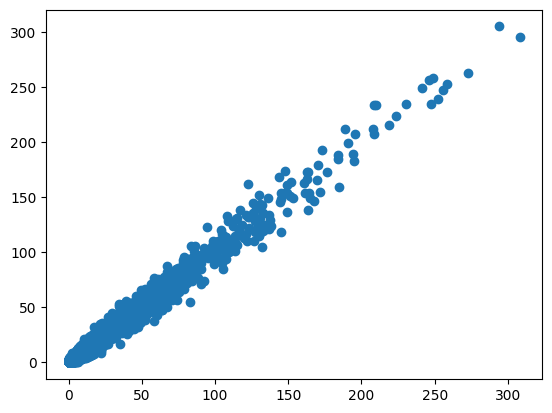

In [32]:
import matplotlib.pyplot as plt
plt.scatter( np.reshape(poislambda( X, alphatrue, betatrue), n ), np.reshape(Y, n) )

Okay, here we go.
Remember, each call to `poistrain` makes a single update to the model parameters.
Write a for-loop to fit a model to the data `(X,Y)` above using 1000 training steps, then plot the loss as a function of the number of steps.
You should:

1. Initialize a model. Don't forget that beta should have dimension that agrees with X above.
2. Initialize a vector in which to store the losses.
3. Perform a for-loop, calling `train` in each iteration and recording the updated loss.
4. Plot the losses over time.

You are free to adapt the code from lecture (also available in the demo code for this week), if you would prefer not to figure all this out from scratch.

Note that you may encounter some errors about invalid values or negative values encountered in logs-- this is usually an indication that your learning rate is set too large.

In [33]:
prm = PoissonRegressionModel(name='prtest', dim=X.shape[1])
(prm.alpha.numpy(), prm.beta.numpy())

(array([0.], dtype=float32),
 array([[0.],
        [0.],
        [0.]], dtype=float32))

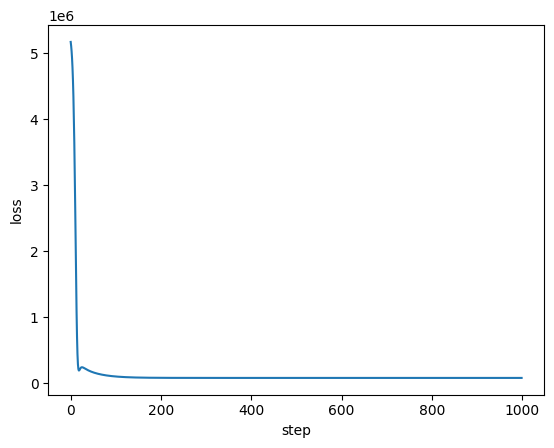

In [34]:
import matplotlib.pyplot as plt

losses = list(range(1000))
for i in range(1000):
    poistrain(prm, X, Y, learning_rate=1e-6)
    losses[i] = loss(Y, prm(X))
plt.xlabel('step'); plt.ylabel('loss'); _ = plt.plot(losses);

In [35]:
(alphatrue, prm.alpha)

(<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.618], dtype=float32)>,
 <tf.Variable 'slope:0' shape=(1,) dtype=float32, numpy=array([1.6191244], dtype=float32)>)

In [36]:
(betatrue, prm.beta)

(<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
 array([[-1.  ],
        [ 0.5 ],
        [ 0.75]], dtype=float32)>,
 <tf.Variable 'intercept:0' shape=(3, 1) dtype=float32, numpy=
 array([[-1.003905  ],
        [ 0.50297445],
        [ 0.7463892 ]], dtype=float32)>)